# AIoT Project

In [1]:
import os

# basic data engineering
import pandas as pd
import numpy as np
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# db
import pymongo

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca

%load_ext autoreload
%autoreload 2

Start time of execution

In [2]:
time_start = time()

## Load configuration

In [3]:
config_path = os.path.join(os.getcwd(), "config.yml")

with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

In [4]:
client = pymongo.MongoClient(config["client"])

In [5]:
db = client[config["db"]]
coll = db[config["col"]]

In [6]:
found_keys = coll.distinct("label")
print("Existing DB keys:", found_keys)

Existing DB keys: []


## Load data

In [7]:
# Fetch all records from the collection
cursor = coll.find({})
data_list = list(cursor)

# Load into DataFrame and drop the MongoDB '_id'
df = pd.DataFrame(data_list)
if not df.empty:
    df = df.drop(columns=['_id'])
    print(f"Successfully loaded {len(df)} total instances across all subjects.")
else:
    print("No data found.")


Successfully loaded 41 total instances across all subjects.


## Explore the nature of the data

In [8]:
# Calculate the number of samples for each instance 
# We take the length of the first list inside the 'data' dictionary
df['num_samples'] = df['data'].apply(lambda x: len(next(iter(x.values()))))

# Calculate time length in seconds (samples / sampling rate)
df['time_length_sec'] = df['num_samples'] / df['sr']

# Calculate time length in minutes for easier reading
df['time_length_min'] = df['time_length_sec'] / 60

# Preview the new columns
df[['gesture_id', 'num_samples', 'time_length_sec', 'time_length_min']].head()

,gesture_id,num_samples,time_length_sec,time_length_min
0,scroll-right-thumb,14428,144.28,2.404667
1,scroll-right-thumb,9321,93.21,1.553500
2,scroll-right-thumb,14515,145.15,2.419167
3,scroll-right-thumb,16851,168.51,2.808500
4,scroll-right-thumb,8268,82.68,1.378000


In [9]:
# Group by gesture class and sum the total time length
time_per_class = df.groupby('gesture_id')['time_length_min'].sum().reset_index()
time_per_class = time_per_class.rename(columns={'time_length_min': 'total_time_min'})

# Display the aggregated data
print(time_per_class)

           gesture_id  total_time_min
0   scroll-down-thumb       14.803667
1   scroll-left-thumb       14.439500
2  scroll-right-thumb       13.953000
3     scroll-up-thumb       14.219667
4       texting-thumb       14.490000


/var/folders/ct/7cmdyst507v1tpdmndr505000000gn/T/ipykernel_67045/840942408.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=time_per_class, x='gesture_id', y='total_time_min', palette='viridis')


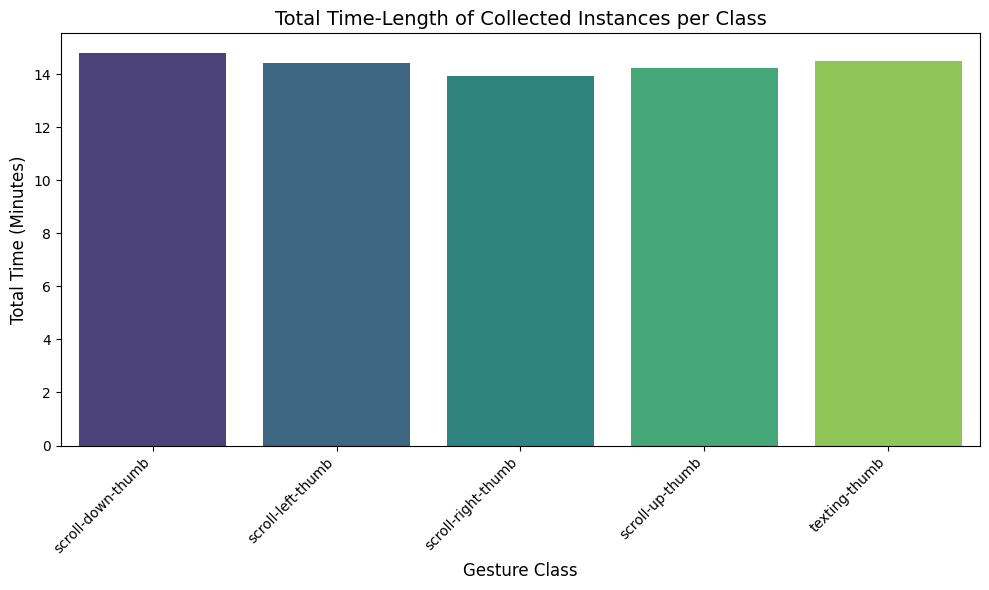

In [10]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Create the barplot
sns.barplot(data=time_per_class, x='gesture_id', y='total_time_min', palette='viridis')

# Add titles and labels
plt.title('Total Time-Length of Collected Instances per Class', fontsize=14)
plt.xlabel('Gesture Class', fontsize=12)
plt.ylabel('Total Time (Minutes)', fontsize=12)

# Rotate the x-axis labels if they are long
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent clipping
plt.tight_layout()

# Show the plot
plt.show()

In [11]:
# Check for missing values in the raw dataset before segmentation
print("Checking for missing values and unequal lengths in the raw continuous data...")
missing_found = False

for index, row in df.iterrows():
    # Convert each array to a pandas Series first. 
    # This forces Pandas to accept unequal lengths by padding the shorter ones with NaNs.
    instance_df = pd.DataFrame({k: pd.Series(v) for k, v in row['data'].items()})
    
    if instance_df.isnull().values.any():
        #print(f"Missing values or unequal lengths found in row {index} (Gesture: {row['gesture_id']}) - Fixing automatically!")
        missing_found = True
        
        # FIXING THE DATA:
        # 1. Interpolate (draw a line) to fill any internal missing packets
        instance_df = instance_df.interpolate(method='linear')
        
        # 2. Drop any remaining NaNs at the very end (truncates all arrays to the length of the shortest one)
        instance_df = instance_df.dropna()
        
        # 3. Save the cleaned data back into our main DataFrame
        df.at[index, 'data'] = instance_df.to_dict('list')

if missing_found:
    print("All missing values and unequal lengths have been successfully cleaned!")
else:
    print("No missing values found in the raw data!")

Checking for missing values and unequal lengths in the raw continuous data...
All missing values and unequal lengths have been successfully cleaned!


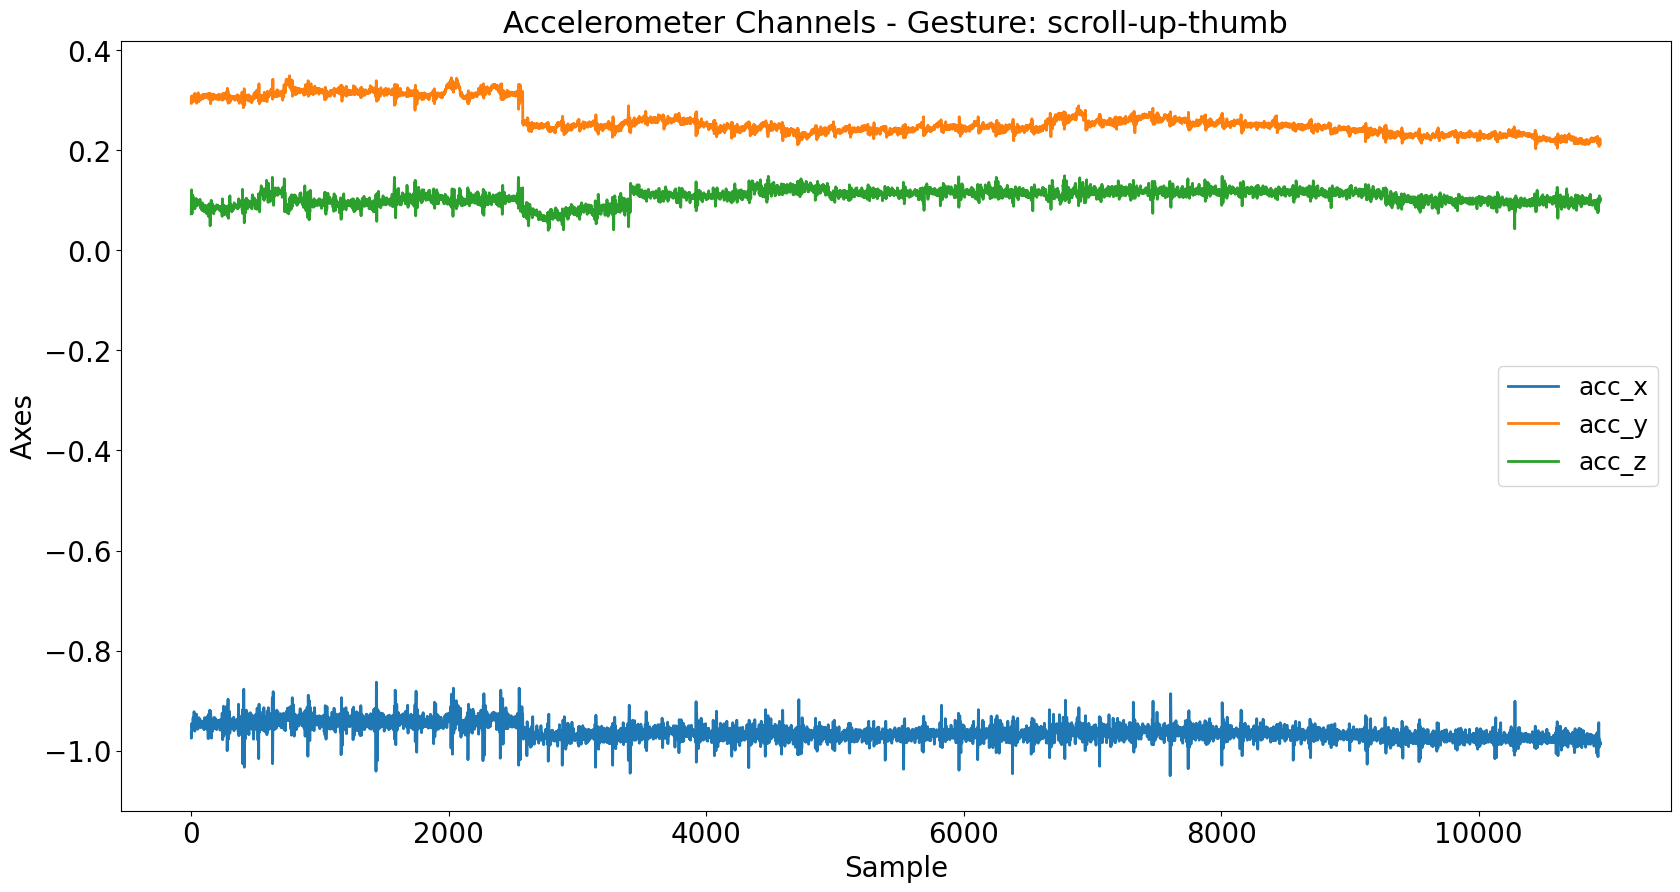

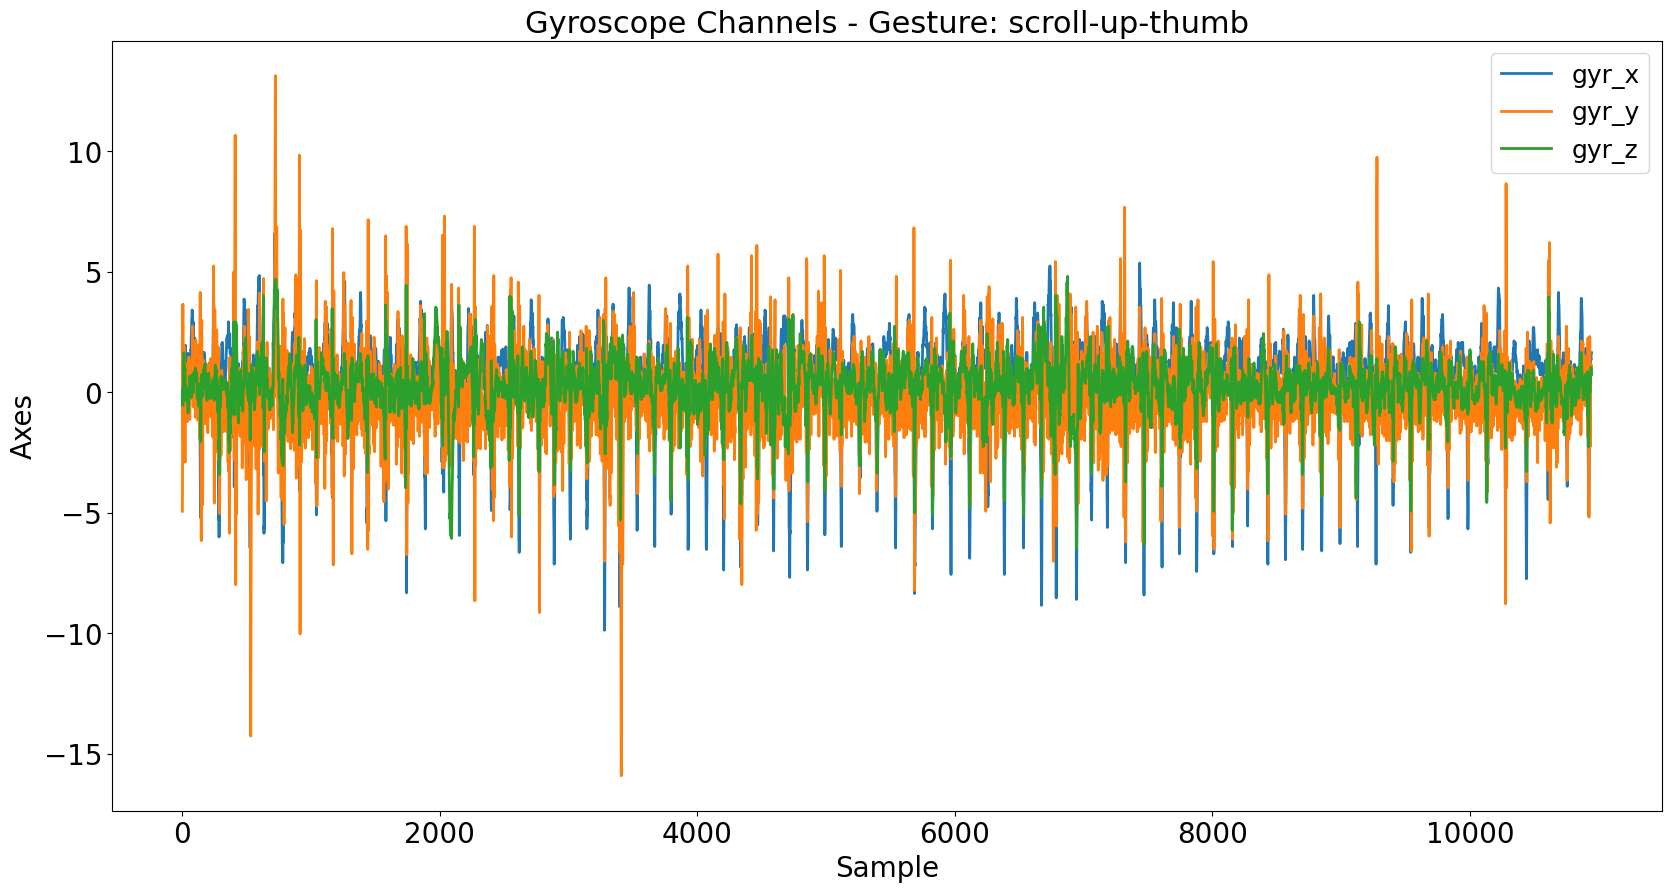

In [12]:
def plot_instance_time_domain(df: pd.DataFrame):
    """Visualizes the movement instance to a plot in time domain.

    Args:
        df: The DataFrame to be visualized in time domain.

    Returns:

    """
    df.plot(figsize=(20, 10), linewidth=2, fontsize=20).legend(fontsize=18)
    plt.xlabel('Sample', fontsize=20)
    plt.ylabel('Axes', fontsize=20)


# 1. Extract a continuous instance from the dataframe (e.g., the first recording)
sample_idx = 30
instance_df = pd.DataFrame(df.iloc[sample_idx]['data'])
gesture_id = df.iloc[sample_idx]['gesture_id'] # Get the gesture ID for the title

# 2. Separate accelerometer and gyroscope columns
acc_cols = [col for col in instance_df.columns if 'acc' in col.lower()]
gyr_cols = [col for col in instance_df.columns if 'gyr' in col.lower()]

# Fallback in case columns aren't explicitly named 'acc'/'gyr'
if not acc_cols:
    acc_cols = instance_df.columns[:3] 
if not gyr_cols:
    gyr_cols = instance_df.columns[3:6] 

# 3. Plot Accelerometer channels (Subplot 1)
plot_instance_time_domain(instance_df[acc_cols])
plt.title(f'Accelerometer Channels - Gesture: {gesture_id}', fontsize=22)
plt.show()

# 4. Plot Gyroscope channels (Subplot 2)
plot_instance_time_domain(instance_df[gyr_cols])
plt.title(f'Gyroscope Channels - Gesture: {gesture_id}', fontsize=22)
plt.show()

In [13]:
from utils import apply_filter

print("Applying lowpass filter to the dataset using utils.py...")

# Extract filter parameters from your config.yml
filter_order = config['filter']['order']
cutoff_freq = config['filter']['wn'] 
filter_type = config['filter']['type']

def filter_session_data(instance_data, sr):
    """
    Wrapper to apply utils.apply_filter to the dictionary of axes,
    handling the Nyquist frequency normalization.
    """
    filtered_data = {}
    
    # 1. Calculate the Nyquist frequency (half of the sampling rate)
    nyquist_freq = 0.5 * sr
    
    # 2. Normalize the cutoff frequency to be between 0 and 1
    normalized_wn = cutoff_freq / nyquist_freq 
    
    for axis_name, values in instance_data.items():
        # 3. Call your existing apply_filter function
        filtered_array = apply_filter(
            arr=values, 
            order=filter_order, 
            wn=normalized_wn,  # MUST use the normalized frequency here
            filter_type=filter_type
        )
        filtered_data[axis_name] = filtered_array.tolist()
        
    return filtered_data

# Apply the filter row by row, respecting the 'sr' of each session
df['filtered_data'] = df.apply(
    lambda row: filter_session_data(row['data'], row['sr']), 
    axis=1
)

print("Filtering complete!")

# Preview the results to verify
df[['gesture_id', 'sr', 'data', 'filtered_data']].head(3)

Applying lowpass filter to the dataset using utils.py...
Filtering complete!


,gesture_id,sr,data,filtered_data
0,scroll-right-thumb,100,"{'acc_x': [-0.901, -0.908, -0.899, -0.894, -0....","{'acc_x': [-0.8982554141130681, -0.89900106418..."
1,scroll-right-thumb,100,"{'acc_x': [-0.723, -0.726, -0.7, -0.697, -0.69...","{'acc_x': [-0.7176631855834499, -0.71172793020..."
2,scroll-right-thumb,100,"{'acc_x': [-0.923, -0.924, -0.949, -0.95, -0.9...","{'acc_x': [-0.9296495708525219, -0.93270685472..."


Plotting RAW data for gesture: scroll-right-thumb (First 300 samples)


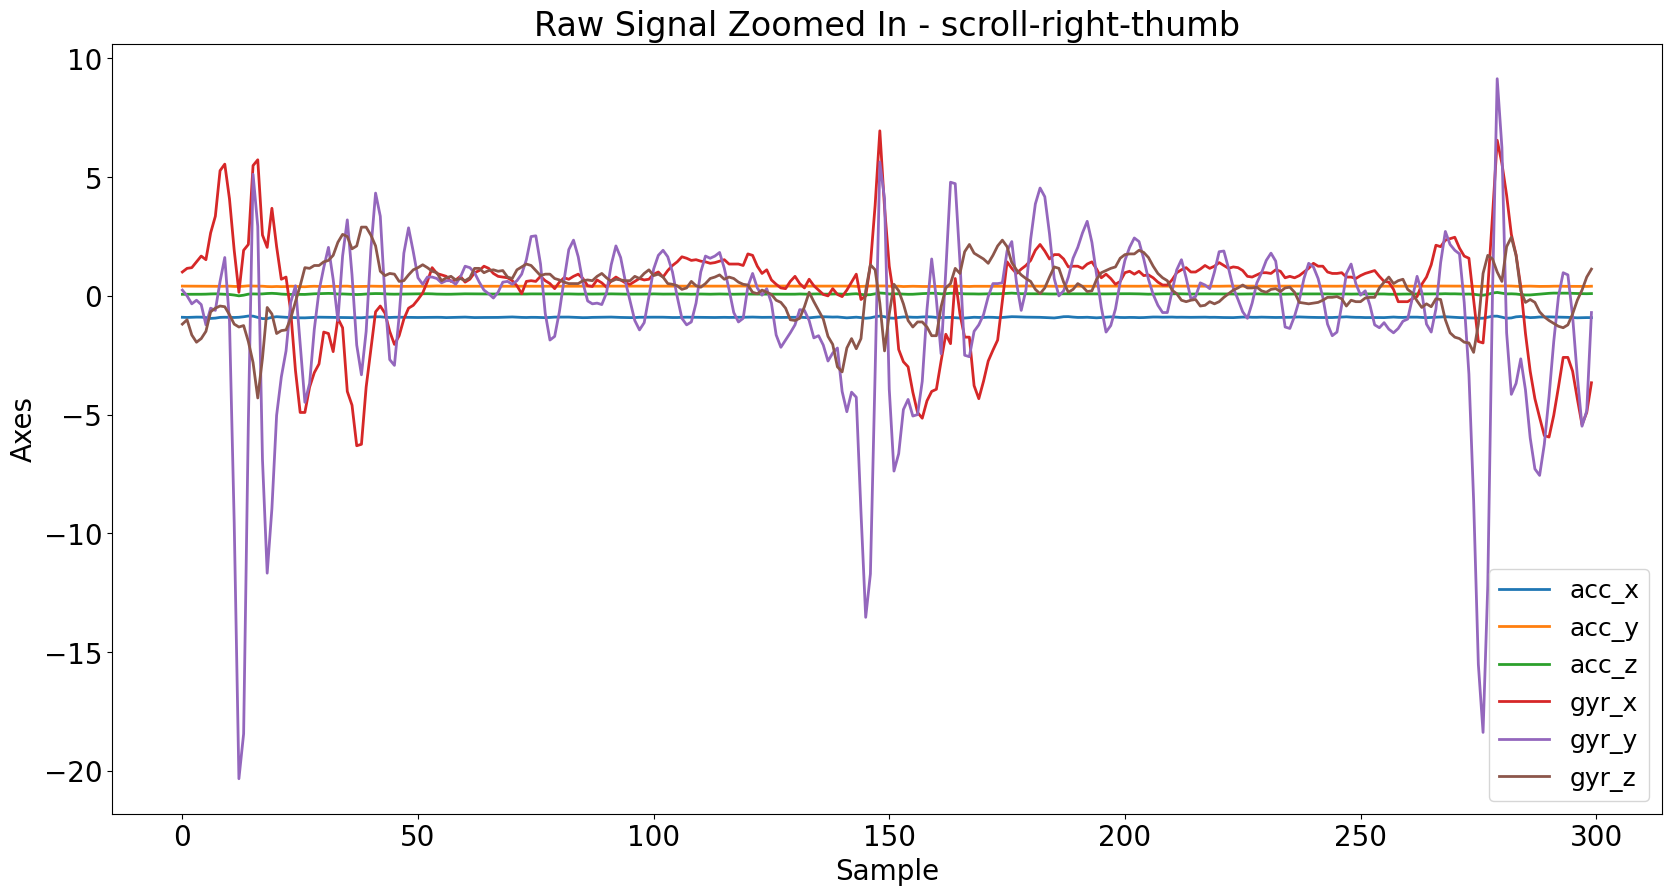

Plotting FILTERED data for gesture: scroll-right-thumb (First 300 samples)


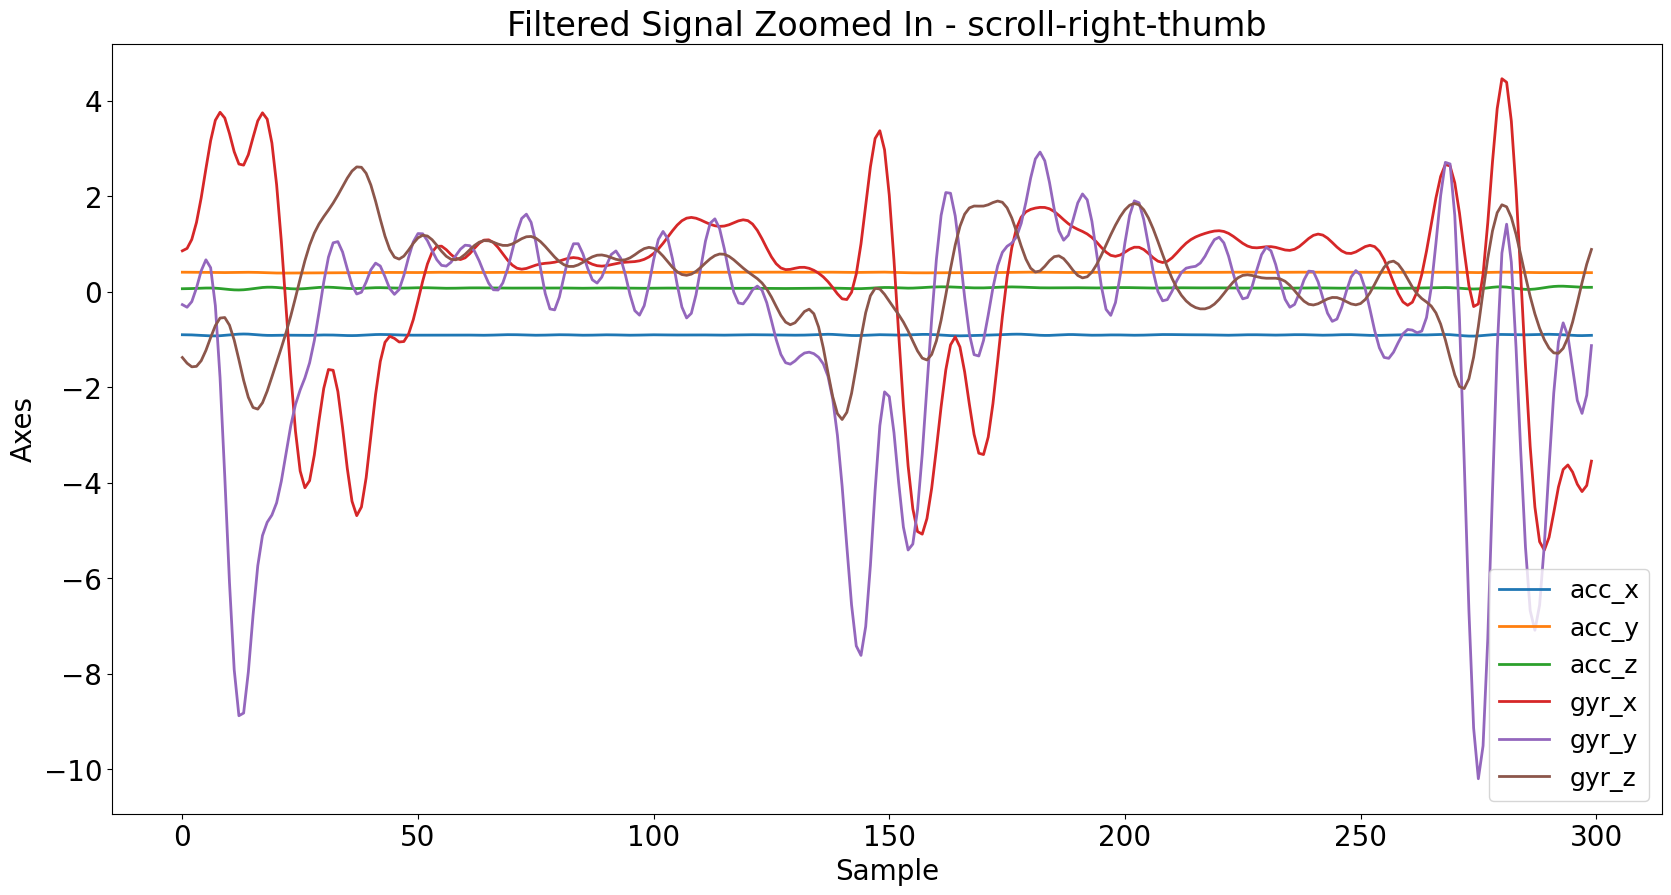

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from utils_visual import plot_instance_time_domain

# 1. Select a single instance (index 0)
sample_idx = 0
raw_data_dict = df.iloc[sample_idx]['data']
filtered_data_dict = df.iloc[sample_idx]['filtered_data']
gesture_label = df.iloc[sample_idx]['gesture_id']

# 2. Convert both data dictionaries into Pandas DataFrames
df_raw = pd.DataFrame(raw_data_dict)
df_filtered = pd.DataFrame(filtered_data_dict)

# 3. Slice the data to view only a specific time frame (e.g., first 300 samples)
zoom_samples = 300 
df_raw_zoomed = df_raw.iloc[:zoom_samples]
df_filtered_zoomed = df_filtered.iloc[:zoom_samples]

# 4. Plot the RAW data
print(f"Plotting RAW data for gesture: {gesture_label} (First {zoom_samples} samples)")
plot_instance_time_domain(df_raw_zoomed)
plt.title(f"Raw Signal Zoomed In - {gesture_label}", fontsize=24)
plt.show()

# 5. Plot the FILTERED data
print(f"Plotting FILTERED data for gesture: {gesture_label} (First {zoom_samples} samples)")
plot_instance_time_domain(df_filtered_zoomed)
plt.title(f"Filtered Signal Zoomed In - {gesture_label}", fontsize=24)
plt.show()

In [55]:
import pandas as pd
from utils import sliding_window_pd

print("Starting sliding window segmentation...")

# 1. Extract parameters from your config.yml
ws = config['sliding_window']['ws']
overlap = config['sliding_window']['overlap']
w_type = config['sliding_window']['w_type']
w_center = config['sliding_window']['w_center']

# Initialize our unified lists
all_windows = [] # This will hold our X (list of Window DataFrames)
all_labels = []  # This will hold our y (list of target gesture_ids)

# 2. Iterate over each recording session independently
for index, row in df.iterrows():
    gesture_label = row['gesture_id']
    filtered_data_dict = row['filtered_data']
    
    # Convert the filtered dictionary back into a Pandas DataFrame
    session_df = pd.DataFrame(filtered_data_dict)
    
    # 3. Apply your existing sliding window function
    # This returns a list of small DataFrames (the windows) for this specific session
    session_windows = sliding_window_pd(
        df=session_df,
        ws=ws,
        overlap=overlap,
        w_type=w_type,
        w_center=w_center,
        print_stats=False # Keep it False so it doesn't flood your Jupyter output
    )
    
    # 4. Add these new windows to our unified master list
    all_windows.extend(session_windows)
    
    # 5. Add the exact same number of labels to our labels list
    all_labels.extend([gesture_label] * len(session_windows))

print("Segmentation complete!")
print(f"Total windows extracted (X): {len(all_windows)}")
print(f"Total labels extracted (y): {len(all_labels)}")

Starting sliding window segmentation...
Segmentation complete!
Total windows extracted (X): 7129
Total labels extracted (y): 7129


In [ ]:
"""
1. label encoding
2. split train/test
3. transform (standardization - scaling)
kai xwrizoume ta arxeia kai blepoyume ti kratame sto kathena
na balw class distribution se shared arxeio
check if windows of the smae gesture look very different
"""

## Data Processing

## Train/Test split

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=True, random_state=42)

## Scaling

In [49]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

## Classifier - Statistical Learning

### Apply simple classifier

In [50]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

### Evaluate simple classifier

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [52]:
from sklearn.metrics import classification_report

### Apply optimization with Grid Search and/or Cross-validation

In [53]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

### Evaluate optimized classifier